<a href="https://colab.research.google.com/github/ingJuanArenas/SimulacionEA2/blob/main/Simulaci%C3%B3nEA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Configuración Inicial y Definición del Modelo Oculto de Markov (HMM)

Primero, importaremos las librerías necesarias y definiremos los parámetros clave de nuestro HMM: los estados ocultos de la máquina, las observaciones de vibración, las matrices de transición y emisión, y la distribución de probabilidad inicial.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import norm

# 1. Definición de Estados y Observaciones

# Estados ocultos (estados internos de la máquina)
hidden_states = ['Estado Normal', 'Estado de Desgaste', 'Estado de Falla']
num_hidden_states = len(hidden_states)
state_to_idx = {state: i for i, state in enumerate(hidden_states)}
idx_to_state = {i: state for i, state in enumerate(hidden_states)}

# Observaciones (niveles de vibración medidos)
observations = ['Vibración Baja', 'Vibración Media', 'Vibración Alta']
num_observations = len(observations)
ob_to_idx = {ob: i for i, ob in enumerate(observations)}
idx_to_ob = {i: ob for i, ob in enumerate(observations)}

print("Estados Ocultos:", hidden_states)
print("Observaciones:", observations)

# 2. Matriz de Transición (A)
# A[i, j] = P(St+1 = estado j | St = estado i)
# Normal -> Desgaste -> Falla
transition_matrix = np.array([
    [0.85, 0.13, 0.02],  # De Normal a (Normal, Desgaste, Falla)
    [0.30, 0.50, 0.20],  # De Desgaste a (Normal, Desgaste, Falla)
    [0.05, 0.15, 0.80]   # De Falla a (Normal, Desgaste, Falla)
])

# 3. Matriz de Emisión (B)
# B[i, j] = P(Ot = observacion j | St = estado i)
#             Baja, Media, Alta
emission_matrix = np.array([
    [0.80, 0.15, 0.05],  # En Estado Normal
    [0.30, 0.50, 0.20],  # En Estado de Desgaste
    [0.10, 0.30, 0.60]   # En Estado de Falla
])

# 4. Distribución Inicial (Pi)
# P(S1 = estado i)
initial_probabilities = np.array([0.80, 0.15, 0.05]) # Normal, Desgaste, Falla

# Validar que las matrices suman 1 en cada fila
print("\nMatriz de Transición:")
print(transition_matrix)
print("Suma de filas de Transición:", transition_matrix.sum(axis=1))

print("\nMatriz de Emisión:")
print(emission_matrix)
print("Suma de filas de Emisión:", emission_matrix.sum(axis=1))

print("\nDistribución Inicial:", initial_probabilities)
print("Suma de Distribución Inicial:", initial_probabilities.sum())


Estados Ocultos: ['Estado Normal', 'Estado de Desgaste', 'Estado de Falla']
Observaciones: ['Vibración Baja', 'Vibración Media', 'Vibración Alta']

Matriz de Transición:
[[0.85 0.13 0.02]
 [0.3  0.5  0.2 ]
 [0.05 0.15 0.8 ]]
Suma de filas de Transición: [1. 1. 1.]

Matriz de Emisión:
[[0.8  0.15 0.05]
 [0.3  0.5  0.2 ]
 [0.1  0.3  0.6 ]]
Suma de filas de Emisión: [1. 1. 1.]

Distribución Inicial: [0.8  0.15 0.05]
Suma de Distribución Inicial: 1.0


### 2. Implementación de la Clase HMM y Simulación de Datos

Crearemos una clase `HMM` que encapsule la lógica del modelo, incluyendo métodos para simular una secuencia de estados ocultos y observaciones, y para generar valores de vibración en Hz basados en las observaciones categóricas. También implementaremos el algoritmo de Viterbi para inferir la secuencia de estados más probable.

In [2]:
class HMM:
    def __init__(self, states, observations, transition_matrix, emission_matrix, initial_probabilities):
        self.states = states
        self.observations = observations
        self.A = transition_matrix # Matriz de transición
        self.B = emission_matrix   # Matriz de emisión
        self.pi = initial_probabilities # Probabilidades iniciales

        self.num_states = len(states)
        self.num_observations = len(observations)
        self.state_to_idx = {state: i for i, state in enumerate(states)}
        self.idx_to_state = {i: state for i, state in enumerate(states)}
        self.ob_to_idx = {ob: i for i, ob in enumerate(observations)}
        self.idx_to_ob = {i: ob for i, ob in enumerate(observations)}

        # Parámetros para generar vibraciones en Hz (media, desviación estándar)
        # Asociamos estos valores a las observaciones categóricas
        self.vibration_params = {
            'Vibración Baja': {'mean': 5, 'std': 1},    # e.g., 4-6 Hz
            'Vibración Media': {'mean': 15, 'std': 2}, # e.g., 10-20 Hz
            'Vibración Alta': {'mean': 30, 'std': 4}   # e.g., 20-40 Hz
        }

    def simulate(self, length):
        # Simula una secuencia de estados ocultos y observaciones
        hidden_state_sequence = []
        observation_sequence = []
        vibration_hz_sequence = []

        # Elegir el estado inicial
        current_state_idx = np.random.choice(self.num_states, p=self.pi)
        hidden_state_sequence.append(self.idx_to_state[current_state_idx])

        for _ in range(length):
            # Generar observación dado el estado actual
            obs_idx = np.random.choice(self.num_observations, p=self.B[current_state_idx])
            observation_sequence.append(self.idx_to_ob[obs_idx])

            # Generar valor de vibración en Hz basado en la observación
            params = self.vibration_params[self.idx_to_ob[obs_idx]]
            vibration_hz = np.random.normal(params['mean'], params['std'])
            vibration_hz_sequence.append(max(0, vibration_hz)) # Asegurarse que no haya vibraciones negativas

            # Transicionar al siguiente estado
            current_state_idx = np.random.choice(self.num_states, p=self.A[current_state_idx])
            hidden_state_sequence.append(self.idx_to_state[current_state_idx])

        # La secuencia de estados ocultos tiene una longitud de (length + 1) si incluimos el estado inicial como primer estado
        # Para propósitos de simulación de eventos, ajustamos para que sean del mismo largo que las observaciones.
        return hidden_state_sequence[:-1], observation_sequence, vibration_hz_sequence

    def viterbi(self, obs_sequence):
        # Implementación del algoritmo de Viterbi para encontrar la secuencia de estados más probable
        T = len(obs_sequence)
        N = self.num_states

        # Convertir secuencia de observaciones a índices
        obs_indices = [self.ob_to_idx[ob] for ob in obs_sequence]

        # Inicialización
        delta = np.zeros((T, N))
        psi = np.zeros((T, N), dtype=int) # Para reconstruir el camino

        delta[0, :] = self.pi * self.B[:, obs_indices[0]]

        # Recursión
        for t in range(1, T):
            for j in range(N):
                # P(observación t | estado j) * max_over_i(P(estado j | estado i) * delta[t-1, i])
                max_prob = np.max(delta[t-1, :] * self.A[:, j])
                delta[t, j] = self.B[j, obs_indices[t]] * max_prob
                psi[t, j] = np.argmax(delta[t-1, :] * self.A[:, j])

        # Terminación
        # El último estado en el camino más probable
        last_state_idx = np.argmax(delta[T-1, :])
        most_likely_path = [last_state_idx]

        # Reconstruir el camino
        for t in range(T - 1, 0, -1):
            last_state_idx = psi[t, last_state_idx]
            most_likely_path.insert(0, last_state_idx)

        return [self.idx_to_state[s_idx] for s_idx in most_likely_path]

    def forward_algorithm(self, obs_sequence):
        # Calcula la probabilidad de las observaciones y las probabilidades de estar en cada estado en cada paso
        T = len(obs_sequence)
        N = self.num_states

        obs_indices = [self.ob_to_idx[ob] for ob in obs_sequence]

        alpha = np.zeros((T, N))

        # Inicialización
        alpha[0, :] = self.pi * self.B[:, obs_indices[0]]

        # Recursión
        for t in range(1, T):
            for j in range(N):
                alpha[t, j] = np.sum(alpha[t-1, :] * self.A[:, j]) * self.B[j, obs_indices[t]]

        # Normalizar alpha para obtener probabilidades de estado suavizadas
        # prob_state_given_obs[t, j] = P(St=j | O_1...O_t)
        state_probabilities = alpha / np.sum(alpha, axis=1)[:, np.newaxis]

        return state_probabilities

# Crear una instancia del HMM
hmm = HMM(hidden_states, observations, transition_matrix, emission_matrix, initial_probabilities)

# Simular 60 horas de operación
simulation_length = 60
true_states, observed_vibrations_cat, vibration_hz = hmm.simulate(simulation_length)

# Inferir la secuencia de estados ocultos más probable usando Viterbi
inferred_states = hmm.viterbi(observed_vibrations_cat)

# Crear un DataFrame para almacenar los resultados de la simulación
sim_df = pd.DataFrame({
    'Hora': range(1, simulation_length + 1),
    'Estado Real': true_states,
    'Vibración Observada Categórica': observed_vibrations_cat,
    'Vibración Hz': vibration_hz,
    'Estado Inferido': inferred_states
})

print("\nPrimeras 5 filas de la simulación:")
display(sim_df.head())

print("\nÚltimas 5 filas de la simulación:")
display(sim_df.tail())



Primeras 5 filas de la simulación:


,Hora,Estado Real,Vibración Observada Categórica,Vibración Hz,Estado Inferido
0,1,Estado Normal,Vibración Media,15.305422,Estado Normal
1,2,Estado Normal,Vibración Baja,4.501329,Estado Normal
2,3,Estado Normal,Vibración Baja,6.713853,Estado Normal
3,4,Estado de Desgaste,Vibración Alta,30.810931,Estado Normal
4,5,Estado Normal,Vibración Baja,4.975629,Estado Normal



Últimas 5 filas de la simulación:


,Hora,Estado Real,Vibración Observada Categórica,Vibración Hz,Estado Inferido
55,56,Estado Normal,Vibración Baja,5.597268,Estado Normal
56,57,Estado Normal,Vibración Media,16.442591,Estado Normal
57,58,Estado Normal,Vibración Media,16.105618,Estado Normal
58,59,Estado Normal,Vibración Baja,4.124743,Estado Normal
59,60,Estado Normal,Vibración Baja,5.073141,Estado Normal


### 3. Visualización de la Vibración y Estados de la Máquina

Ahora visualizaremos la vibración generada en Hz a lo largo del tiempo, coloreando las zonas según el **estado inferido** de la máquina. Esto nos dará una vista clara de cómo la vibración se relaciona con el estado operativo de la máquina.

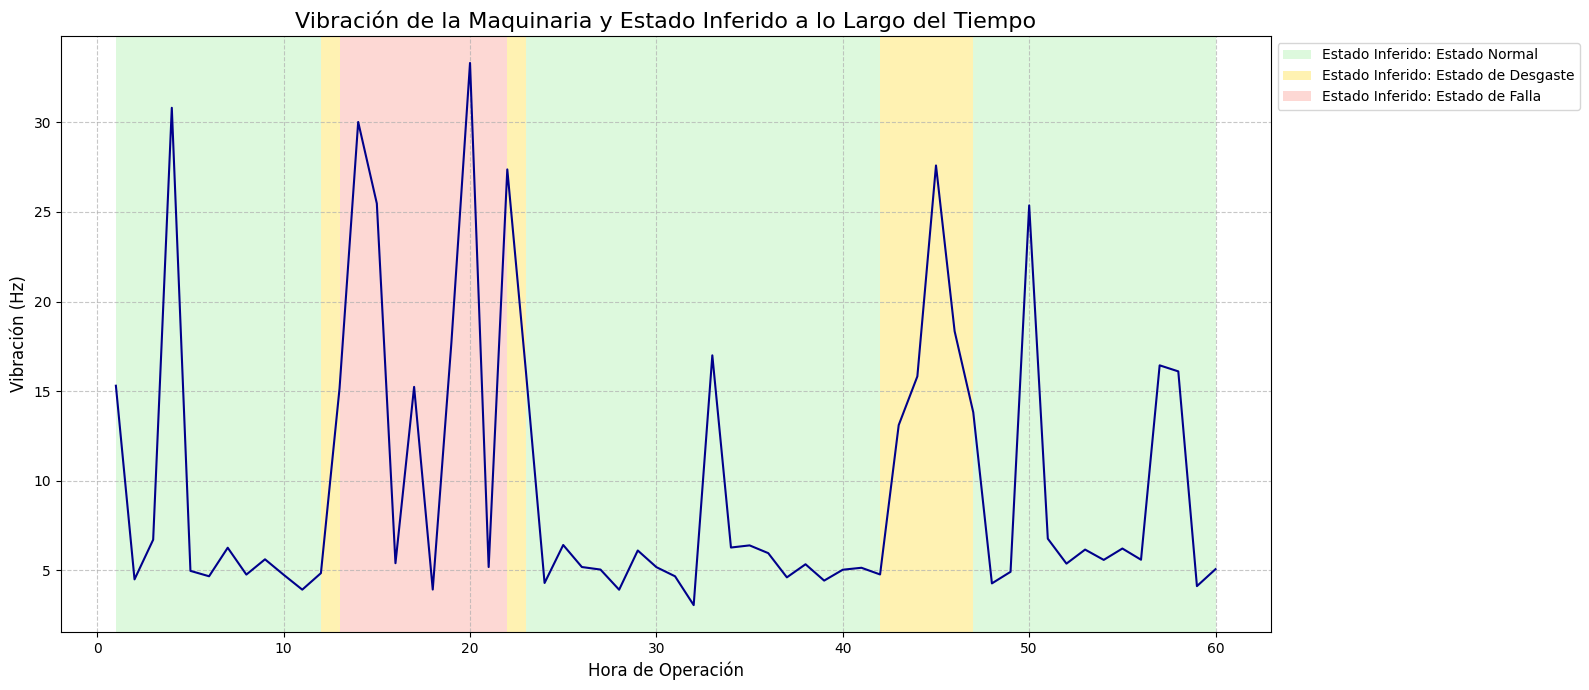

In [3]:
plt.figure(figsize=(16, 7))
sns.lineplot(x='Hora', y='Vibración Hz', data=sim_df, color='darkblue', linewidth=1.5)

# Colorear zonas según el estado inferido
state_colors = {
    'Estado Normal': 'lightgreen',
    'Estado de Desgaste': 'gold',
    'Estado de Falla': 'salmon'
}

# Para colorear las regiones de manera continua, identificamos cambios de estado
current_state = inferred_states[0]
start_hour = 1
for i in range(1, simulation_length):
    if inferred_states[i] != current_state:
        plt.axvspan(start_hour, i, facecolor=state_colors[current_state], alpha=0.3, label=f'Estado Inferido: {current_state}' if f'Estado Inferido: {current_state}' not in plt.gca().get_legend_handles_labels()[1] else "")
        current_state = inferred_states[i]
        start_hour = i
# Colorear la última sección
plt.axvspan(start_hour, simulation_length, facecolor=state_colors[current_state], alpha=0.3, label=f'Estado Inferido: {current_state}' if f'Estado Inferido: {current_state}' not in plt.gca().get_legend_handles_labels()[1] else "")


plt.title('Vibración de la Maquinaria y Estado Inferido a lo Largo del Tiempo', fontsize=16)
plt.xlabel('Hora de Operación', fontsize=12)
plt.ylabel('Vibración (Hz)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


### 4. Análisis de Tendencia de Degradación y Probabilidades de Estado

Para un mantenimiento predictivo efectivo, es crucial entender la probabilidad de que la máquina se encuentre en cada estado en cada momento. Usaremos el algoritmo Forward para calcular estas probabilidades suavizadas y visualizaremos la tendencia de degradación (probabilidad de 'Desgaste' o 'Falla').

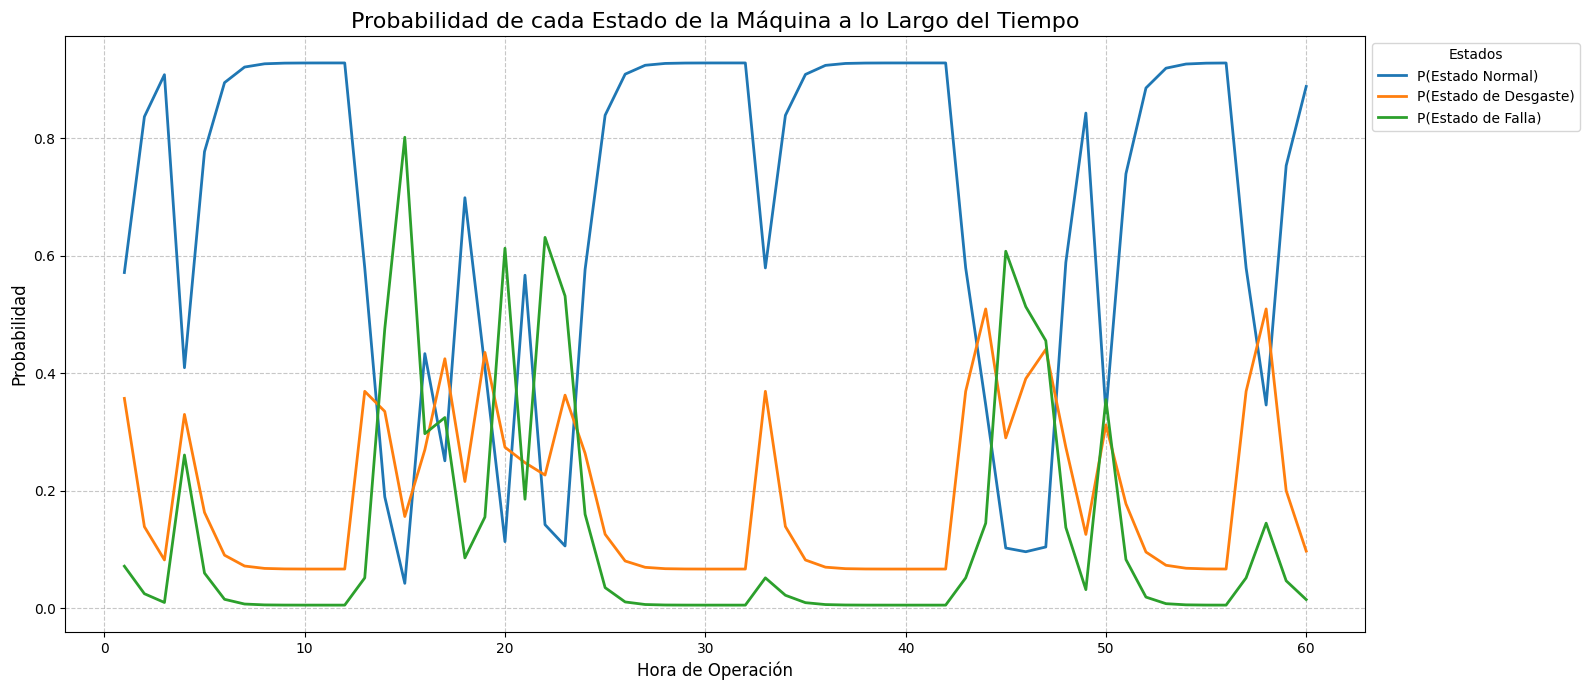


Primeras 5 filas del DataFrame con probabilidades de estado:


,Hora,Estado Real,Vibración Observada Categórica,Vibración Hz,Estado Inferido,Probabilidad Estado Normal,Probabilidad Estado de Desgaste,Probabilidad Estado de Falla
0,1,Estado Normal,Vibración Media,15.305422,Estado Normal,0.571429,0.357143,0.071429
1,2,Estado Normal,Vibración Baja,4.501329,Estado Normal,0.836778,0.138670,0.024552
2,3,Estado Normal,Vibración Baja,6.713853,Estado Normal,0.908237,0.082110,0.009652
3,4,Estado de Desgaste,Vibración Alta,30.810931,Estado Normal,0.409384,0.329870,0.260746
4,5,Estado Normal,Vibración Baja,4.975629,Estado Normal,0.777254,0.163021,0.059725


In [4]:
# Calcular las probabilidades de estado en cada paso usando el algoritmo Forward
state_probabilities = hmm.forward_algorithm(observed_vibrations_cat)

# Añadir estas probabilidades al DataFrame de simulación
for i, state in enumerate(hidden_states):
    sim_df[f'Probabilidad {state}'] = state_probabilities[:, i]

plt.figure(figsize=(16, 7))
# Gráfico de probabilidades de estado
for i, state in enumerate(hidden_states):
    plt.plot(sim_df['Hora'], sim_df[f'Probabilidad {state}'], label=f'P({state})', linewidth=2)

plt.title('Probabilidad de cada Estado de la Máquina a lo Largo del Tiempo', fontsize=16)
plt.xlabel('Hora de Operación', fontsize=12)
plt.ylabel('Probabilidad', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Estados', bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\nPrimeras 5 filas del DataFrame con probabilidades de estado:")
display(sim_df.head())


### 5. Métricas de Mantenimiento y Sistema de Alertas Tempranas

Ahora calcularemos métricas clave como el Tiempo Medio Entre Fallas (MTBF), el Tiempo de Vida Útil Restante (RUL), y definiremos un sistema de alertas. Dado que la simulación es corta, algunas métricas serán conceptuales o se basarán en las inferencias.

In [5]:
# --- Métricas de Mantenimiento ---

# 1. Tiempo Medio Entre Fallas (MTBF)
# Para esta simulación, definiremos una falla como estar en 'Estado de Falla'.
# Calculamos el tiempo promedio entre las ocurrencias de 'Estado de Falla' después de un 'Estado Normal' o 'Desgaste'.

failure_starts = []
last_non_failure_time = 0
for i in range(1, simulation_length):
    if inferred_states[i] == 'Estado de Falla' and inferred_states[i-1] != 'Estado de Falla':
        failure_starts.append(i - last_non_failure_time)
    if inferred_states[i] != 'Estado de Falla': # Si salimos del estado de falla, resetear
        last_non_failure_time = i

mtbf = np.mean(failure_starts) if failure_starts else float('inf') # Si no hay fallas, MTBF es infinito
print(f"\nMTBF (Tiempo Medio Entre Fallas): {mtbf:.2f} horas")

# 2. Tiempo de Vida Útil Restante (RUL - Remaining Useful Life)
# El RUL se estima desde el estado actual hasta la próxima falla. Es una métrica predictiva.
# Usaremos la probabilidad de transitar al estado de falla desde el estado inferido actual.

current_inferred_state_idx = hmm.state_to_idx[inferred_states[-1]]
prob_to_fail_from_current = hmm.A[current_inferred_state_idx, hmm.state_to_idx['Estado de Falla']]

if prob_to_fail_from_current > 0:
    # RUL como el inverso de la probabilidad de falla en el siguiente paso (una heurística simple)
    estimated_rul = 1 / prob_to_fail_from_current
else:
    estimated_rul = float('inf')

print(f"RUL estimado (basado en el último estado inferido): {estimated_rul:.2f} horas")

# 3. Ventana Óptima para Mantenimiento Preventivo
# Se define como el momento en que la probabilidad de 'Estado de Desgaste' o 'Falla' excede un umbral.
wear_threshold = 0.5 # Umbral de probabilidad para 'Estado de Desgaste'
fail_threshold = 0.2 # Umbral de probabilidad para 'Estado de Falla'

preventive_maintenance_windows = []
alert_triggered = False
for i in range(simulation_length):
    if sim_df.loc[i, 'Probabilidad Estado de Desgaste'] > wear_threshold and not alert_triggered:
        preventive_maintenance_windows.append(i + 1) # Hora de inicio de la ventana
        alert_triggered = True
    elif sim_df.loc[i, 'Probabilidad Estado de Desgaste'] <= wear_threshold:
        alert_triggered = False # Resetear alerta si la probabilidad baja

print(f"Ventanas sugeridas para Mantenimiento Preventivo (al superar {wear_threshold*100}% prob. de Desgaste): {preventive_maintenance_windows}")

# 4. Costo Estimado de No Hacer Mantenimiento (ejemplo conceptual)
cost_per_hour_normal = 10
cost_per_hour_wear = 50
cost_per_hour_failure = 500 # Mucho más alto si la máquina falla

total_cost_if_no_maintenance = 0
for i in range(simulation_length):
    state = inferred_states[i]
    if state == 'Estado Normal':
        total_cost_if_no_maintenance += cost_per_hour_normal
    elif state == 'Estado de Desgaste':
        total_cost_if_no_maintenance += cost_per_hour_wear
    elif state == 'Estado de Falla':
        total_cost_if_no_maintenance += cost_per_hour_failure

print(f"Costo estimado acumulado si no se realiza mantenimiento (simulado): ${total_cost_if_no_maintenance:.2f}")


# --- Sistema de Alertas Tempranas ---
alert_threshold_wear = 0.6 # Probabilidad de 'Desgaste' para alerta
alert_threshold_failure = 0.3 # Probabilidad de 'Falla' para alerta crítica

alert_messages = []
for i in range(simulation_length):
    hora = i + 1
    prob_wear = sim_df.loc[i, 'Probabilidad Estado de Desgaste']
    prob_failure = sim_df.loc[i, 'Probabilidad Estado de Falla']

    if prob_failure > alert_threshold_failure:
        alert_messages.append(f"CRÍTICA (Hora {hora}): ¡ALERTA ROJA! Alta probabilidad de FALLA ({prob_failure:.2f}). Se requiere intervención inmediata.")
    elif prob_wear > alert_threshold_wear:
        alert_messages.append(f"ADVERTENCIA (Hora {hora}): Probabilidad significativa de DESGASTE ({prob_wear:.2f}). Se recomienda inspección/mantenimiento preventivo.")

if alert_messages:
    print("\n--- Registro de Alertas del Sistema ---")
    for msg in alert_messages:
        print(msg)
else:
    print("\nNo se activaron alertas de desgaste o falla significativa en esta simulación.")



MTBF (Tiempo Medio Entre Fallas): 1.00 horas
RUL estimado (basado en el último estado inferido): 50.00 horas
Ventanas sugeridas para Mantenimiento Preventivo (al superar 50.0% prob. de Desgaste): [44, 58]
Costo estimado acumulado si no se realiza mantenimiento (simulado): $5290.00

--- Registro de Alertas del Sistema ---
CRÍTICA (Hora 14): ¡ALERTA ROJA! Alta probabilidad de FALLA (0.48). Se requiere intervención inmediata.
CRÍTICA (Hora 15): ¡ALERTA ROJA! Alta probabilidad de FALLA (0.80). Se requiere intervención inmediata.
CRÍTICA (Hora 17): ¡ALERTA ROJA! Alta probabilidad de FALLA (0.32). Se requiere intervención inmediata.
CRÍTICA (Hora 20): ¡ALERTA ROJA! Alta probabilidad de FALLA (0.61). Se requiere intervención inmediata.
CRÍTICA (Hora 22): ¡ALERTA ROJA! Alta probabilidad de FALLA (0.63). Se requiere intervención inmediata.
CRÍTICA (Hora 23): ¡ALERTA ROJA! Alta probabilidad de FALLA (0.53). Se requiere intervención inmediata.
CRÍTICA (Hora 45): ¡ALERTA ROJA! Alta probabilidad d

### 6. Predicción de Próxima Falla y Recomendaciones de Mantenimiento

Para predecir cuándo ocurrirá la próxima falla y generar recomendaciones, utilizaremos las probabilidades de transición y el estado actual de la máquina. Esto simula cómo un sistema de mantenimiento predictivo podría guiar las decisiones.

In [6]:
print("\n--- Predicción de Próxima Falla y Recomendaciones ---")

current_state_str = inferred_states[-1] # Último estado inferido
current_state_idx = hmm.state_to_idx[current_state_str]

# Predecir el siguiente estado más probable
next_state_probs = hmm.A[current_state_idx, :]
predicted_next_state_idx = np.argmax(next_state_probs)
predicted_next_state_str = hmm.idx_to_state[predicted_next_state_idx]

print(f"Estado actual inferido (Hora {simulation_length}): {current_state_str}")
print(f"El estado más probable en la siguiente hora es: {predicted_next_state_str} (con probabilidad {next_state_probs[predicted_next_state_idx]:.2f})")

# Predicción a N pasos (ej. 5 pasos adelante)
def predict_future_states(hmm_model, start_state_idx, num_steps):
    future_states = []
    current_state_prob_dist = np.zeros(hmm_model.num_states)
    current_state_prob_dist[start_state_idx] = 1.0

    for _ in range(num_steps):
        # Multiplicar por la matriz de transición para obtener la distribución de probabilidad del siguiente paso
        current_state_prob_dist = np.dot(current_state_prob_dist, hmm_model.A)
        # El estado más probable en este paso
        future_states.append(hmm_model.idx_to_state[np.argmax(current_state_prob_dist)])
    return future_states, current_state_prob_dist

future_steps = 5
predicted_path, final_prob_dist = predict_future_states(hmm, current_state_idx, future_steps)

print(f"Secuencia de estados más probable en los próximos {future_steps} pasos: {predicted_path}")
prob_fail_future = final_prob_dist[hmm.state_to_idx['Estado de Falla']]
print(f"Probabilidad acumulada de estar en 'Estado de Falla' en {future_steps} pasos: {prob_fail_future:.2f}")

# -- Recomendaciones de Mantenimiento --
print("\n--- Recomendaciones de Mantenimiento ---")
if 'Estado de Falla' in predicted_path or current_state_str == 'Estado de Falla' or prob_fail_future > 0.5:
    print("RECOMENDACIÓN CRÍTICA: La máquina está en o se dirige rápidamente a un 'Estado de Falla'. Se recomienda detener la operación inmediatamente para inspección y reparación mayor. Es probable que se necesite reemplazo de componentes críticos.")
elif 'Estado de Desgaste' in predicted_path or current_state_str == 'Estado de Desgaste' or prob_fail_future > 0.1:
    print("RECOMENDACIÓN URGENTE: La máquina muestra signos de 'Estado de Desgaste'. Se recomienda programar mantenimiento preventivo detallado y monitoreo intensivo. Considere la sustitución de piezas con vida útil limitada.")
elif 'Estado Normal' == current_state_str:
    print("RECOMENDACIÓN ESTÁNDAR: La máquina opera en 'Estado Normal'. Continuar con el monitoreo rutinario y el programa de mantenimiento preventivo estándar. No se requiere intervención inmediata.")
else:
    print("RECOMENDACIÓN: Revise el historial de alertas y las tendencias de degradación para determinar el mejor curso de acción.")



--- Predicción de Próxima Falla y Recomendaciones ---
Estado actual inferido (Hora 60): Estado Normal
El estado más probable en la siguiente hora es: Estado Normal (con probabilidad 0.85)
Secuencia de estados más probable en los próximos 5 pasos: ['Estado Normal', 'Estado Normal', 'Estado Normal', 'Estado Normal', 'Estado Normal']
Probabilidad acumulada de estar en 'Estado de Falla' en 5 pasos: 0.16

--- Recomendaciones de Mantenimiento ---
RECOMENDACIÓN URGENTE: La máquina muestra signos de 'Estado de Desgaste'. Se recomienda programar mantenimiento preventivo detallado y monitoreo intensivo. Considere la sustitución de piezas con vida útil limitada.


### 7. Dashboard de Salud de la Máquina y Reporte con Semáforo

Para integrar toda la información de manera visual y práctica, crearemos un dashboard de tipo industrial que muestre el estado actual, las tendencias y las alertas. Incluiremos un "semáforo" para una indicación rápida de la salud de la máquina.

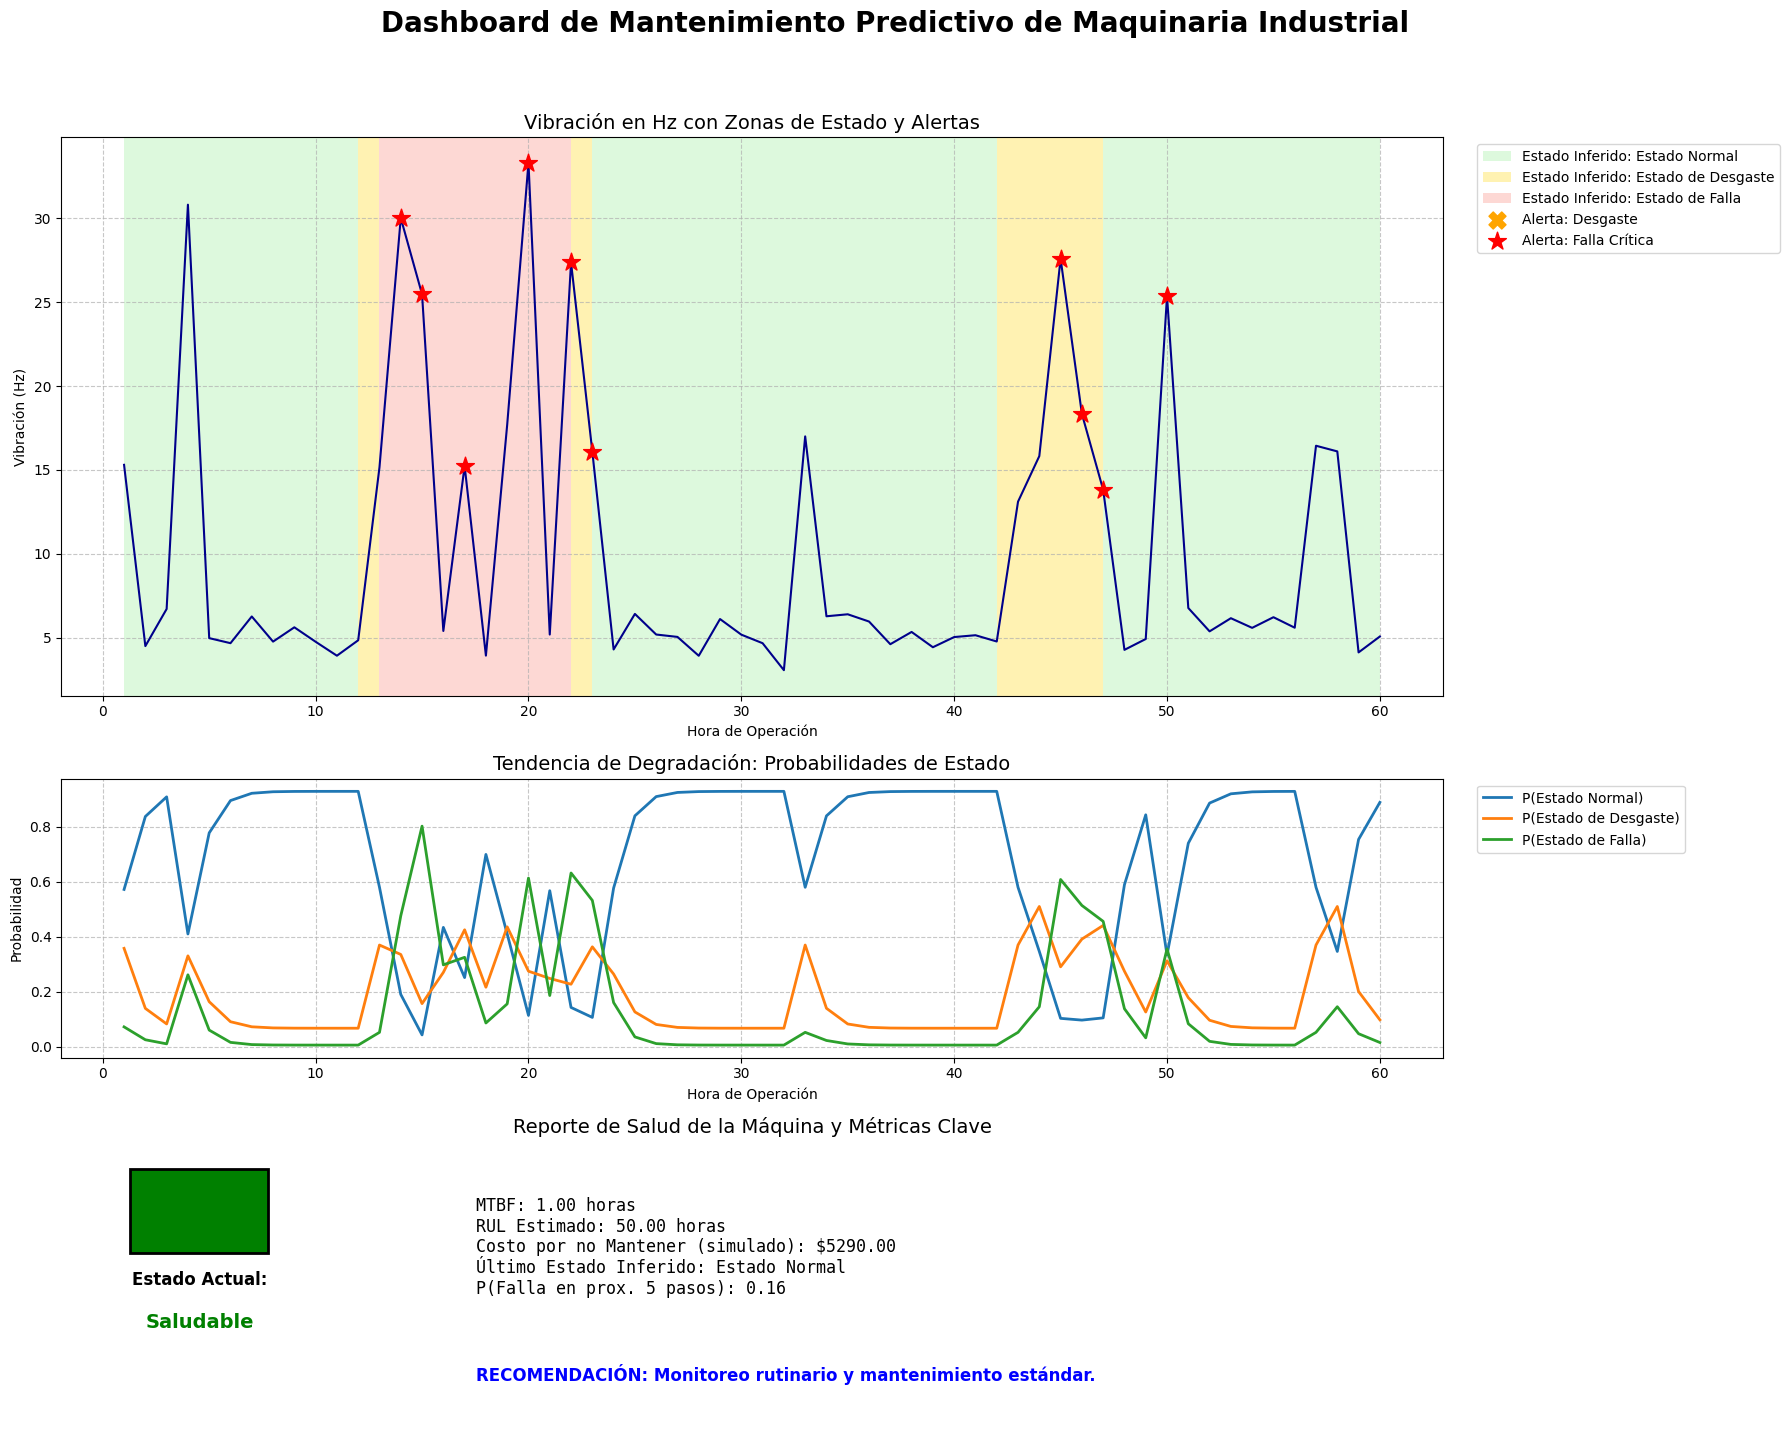

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(18, 15), gridspec_kw={'height_ratios': [2, 1, 1]})
fig.suptitle('Dashboard de Mantenimiento Predictivo de Maquinaria Industrial', fontsize=20, weight='bold')

# --- Panel 1: Vibración y Estados Inferidos (Dashboard Principal) ---
ax0 = axes[0]
sns.lineplot(x='Hora', y='Vibración Hz', data=sim_df, color='darkblue', linewidth=1.5, ax=ax0)

# Colorear zonas de estado inferido
current_state = inferred_states[0]
start_hour = 1
for i in range(1, simulation_length):
    if inferred_states[i] != current_state:
        ax0.axvspan(start_hour, i, facecolor=state_colors[current_state], alpha=0.3, label=f'Estado Inferido: {current_state}' if f'Estado Inferido: {current_state}' not in ax0.get_legend_handles_labels()[1] else "")
        current_state = inferred_states[i]
        start_hour = i
ax0.axvspan(start_hour, simulation_length, facecolor=state_colors[current_state], alpha=0.3, label=f'Estado Inferido: {current_state}' if f'Estado Inferido: {current_state}' not in ax0.get_legend_handles_labels()[1] else "")

# Indicadores de Alerta de Mantenimiento
alert_points_critical = sim_df[sim_df['Probabilidad Estado de Falla'] > alert_threshold_failure]
alert_points_warning = sim_df[(sim_df['Probabilidad Estado de Desgaste'] > alert_threshold_wear) & (sim_df['Probabilidad Estado de Falla'] <= alert_threshold_failure)]

ax0.scatter(alert_points_warning['Hora'], alert_points_warning['Vibración Hz'], color='orange', s=150, marker='X', zorder=5, label='Alerta: Desgaste')
ax0.scatter(alert_points_critical['Hora'], alert_points_critical['Vibración Hz'], color='red', s=180, marker='*', zorder=5, label='Alerta: Falla Crítica')

ax0.set_title('Vibración en Hz con Zonas de Estado y Alertas', fontsize=14)
ax0.set_xlabel('Hora de Operación', fontsize=10)
ax0.set_ylabel('Vibración (Hz)', fontsize=10)
ax0.grid(True, linestyle='--', alpha=0.7)
ax0.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

# --- Panel 2: Probabilidades de Estado (Tendencia de Degradación) ---
ax1 = axes[1]
for i, state in enumerate(hidden_states):
    ax1.plot(sim_df['Hora'], sim_df[f'Probabilidad {state}'], label=f'P({state})', linewidth=2)
ax1.set_title('Tendencia de Degradación: Probabilidades de Estado', fontsize=14)
ax1.set_xlabel('Hora de Operación', fontsize=10)
ax1.set_ylabel('Probabilidad', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

# --- Panel 3: Reporte de Salud de la Máquina (Semáforo y Métricas Clave) ---
ax2 = axes[2]
ax2.axis('off') # Ocultar ejes para un reporte basado en texto/rectángulos

# Semáforo de Salud
current_health_color = 'green' # Default
health_status = 'Saludable'
if inferred_states[-1] == 'Estado de Desgaste' or sim_df['Probabilidad Estado de Desgaste'].iloc[-1] > 0.5:
    current_health_color = 'yellow'
    health_status = 'Advertencia: Desgaste'
if inferred_states[-1] == 'Estado de Falla' or sim_df['Probabilidad Estado de Falla'].iloc[-1] > 0.2:
    current_health_color = 'red'
    health_status = 'CRÍTICO: Falla'

# Dibujar el semáforo
ax2.add_patch(plt.Rectangle((0.05, 0.6), 0.1, 0.3, facecolor=current_health_color, edgecolor='black', lw=2))
ax2.text(0.1, 0.5, 'Estado Actual:', fontsize=12, weight='bold', ha='center', va='center')
ax2.text(0.1, 0.35, health_status, fontsize=14, weight='bold', color=current_health_color, ha='center', va='center')

# Mostrar métricas clave
metrics_text = f""
metrics_text += f"MTBF: {mtbf:.2f} horas\n"
metrics_text += f"RUL Estimado: {estimated_rul:.2f} horas\n"
metrics_text += f"Costo por no Mantener (simulado): ${total_cost_if_no_maintenance:.2f}\n"
metrics_text += f"Último Estado Inferido: {inferred_states[-1]}\n"
metrics_text += f"P(Falla en prox. {future_steps} pasos): {prob_fail_future:.2f}\n"

# Recomendación principal
recommendation_text = "RECOMENDACIÓN: "
if current_health_color == 'red':
    recommendation_text += "Detención inmediata y reparación mayor."
elif current_health_color == 'yellow':
    recommendation_text += "Mantenimiento preventivo detallado y monitoreo."
else:
    recommendation_text += "Monitoreo rutinario y mantenimiento estándar."

ax2.text(0.3, 0.8, metrics_text, fontsize=12, va='top', ha='left', family='monospace')
ax2.text(0.3, 0.2, recommendation_text, fontsize=12, va='top', ha='left', wrap=True, color='blue', weight='bold')

ax2.set_title('Reporte de Salud de la Máquina y Métricas Clave', fontsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar layout para el título principal
plt.savefig("SEA2.png")
plt.show()
